In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd

from tqdm import tqdm
import h5py

from multicam_tng.utils import convert_tng_mass, get_color, get_color_and_match, get_msmhmr

from multicam.multicam import MultiCamSampling, MultiCAM

from multicam_tng.utils import TNG_H

In [2]:
# stellar mass of 100 particles (should be the lowest mass we consider)
np.log10(1.4e6 * 100 * TNG_H)

np.float64(7.97697322798685)

In [7]:
# read tree data 
hydro_data = {} 
with open("../../data/out-trees-tng100-bar.npz", 'rb') as fp:
    out = np.load(fp)
    for k in out: 
        hydro_data[k] = out[k]


In [ ]:
# how complete? 
# compute number of galaxies in stellar bin that are not in mpeak bin
cond1 = (hydro_data['stellar_mass'] > 10**9.5 ) & (hydro_data['stellar_mass'] < 10**10.2 )
cond2 = (hydro_data['mpeak'] < 10**11 ) | (hydro_data['mpeak'] > 10**12 )
sum(cond1 & cond2) / sum(cond1) # ~ 1% is OK

np.float64(0.013070283600493218)

In [8]:
hydro_data.keys()

dict_keys(['subfind_id', 'vpeak', 'mpeak_mah', 'is_sub', 'a12', 'mpeak_pre', 'mpeak', 'stellar_mass'])

In [9]:
# sort array by subfind ids to match with color data
_sort_mask = np.argsort(hydro_data['subfind_id'])
for k in hydro_data:
    hydro_data[k] = hydro_data[k][_sort_mask]

In [27]:
hydro_data['subfind_id'], hydro_data['stellar_mass'], hydro_data['mpeak']

(array([      0,       1,       2, ..., 3577883, 3741554, 4263941],
       shape=(101431,)),
 array([1.6383422e+12, 2.5731015e+11, 2.8852679e+11, ..., 1.9287528e+06,
        0.0000000e+00, 0.0000000e+00], shape=(101431,), dtype=float32),
 array([2.7477936e+14, 3.7301757e+13, 4.1831337e+13, ..., 1.8157779e+10,
        1.0704213e+10, 1.3181168e+10], shape=(101431,), dtype=float32))

In [ ]:
# define stellar mass bin to be used throughout

stellar_mass_bin = (9.5, 10.2 ) # log10 Msun / h units 
cond1 = hydro_data['stellar_mass'] > 10**stellar_mass_bin[0]
cond2 = hydro_data['stellar_mass'] < 10**stellar_mass_bin[1]
stellar_mask = cond1 & cond2
sum(stellar_mask)

np.int64(4055)

In [14]:
# see notebook "2025-11-10 Mass bin MultiCAM Trying Mpeak"
mpeak_mass_bin = (11, 12) # log10 Msun / h units 

mpeak = np.log10(hydro_data['mpeak']) # min = 1e10
left_cond = mpeak > mpeak_mass_bin[0]
right_cond = mpeak < mpeak_mass_bin[1]
# star_cond =hydro_data['stellar_mass'] > 0
star_cond = hydro_data['stellar_mass'] > np.log10(1.4e6 * 100 * TNG_H)
mpeak_mask = left_cond & right_cond & star_cond
sum(mpeak_mask)

np.int64(11316)

In [16]:
# get colors
color_file = "../../data/Subhalo_StellarPhot_p07c_cf00dust_res_conv_ns1_rad30pkpc_099.hdf5"
colors = get_color_and_match(color_file, hydro_data['subfind_id'])
gi_color = colors['sdss_g'].values - colors['sdss_i'].values
gi_color.shape

(101431,)

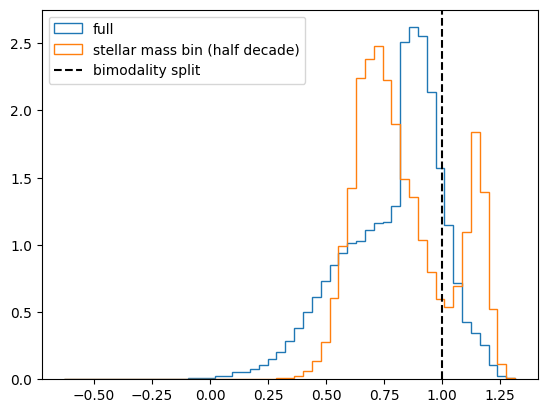

In [17]:
_, bins, _ = plt.hist(gi_color, bins=51, density=True, histtype='step', label='full');

# just as an example to see bimodality
plt.hist(gi_color[stellar_mask], bins=bins, density=True, 
         histtype='step', label='stellar mass bin (half decade)');

plt.axvline(1.0, c='k', ls='--', label='bimodality split')
plt.legend()


Text(0, 0.5, 'log10 Stellar Mass')

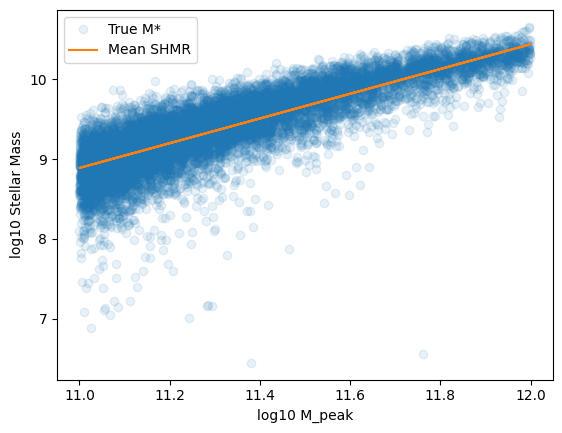

In [32]:
# get deviation from mean SHMR and check that it looks correct
_smass = np.log10(hydro_data['stellar_mass'][mpeak_mask])
_mpeak =  mpeak[mpeak_mask] # already log10

mstar_dev, (m, b) = get_msmhmr(_smass,_mpeak, n_bins=11, mass_bin=mpeak_mass_bin)

_y_pred = np.log10(10 ** (m * _mpeak + b) * 10**_mpeak)
plt.plot(_mpeak, _smass, 'o', alpha=0.1, label='True M*')
plt.plot(_mpeak, _y_pred, '-', label="Mean SHMR")
plt.legend()

plt.xlabel("log10 M_peak")
plt.ylabel("log10 Stellar Mass") 



In [28]:
# get snapshot redshifts and scales
import pandas as pd
metadata = pd.read_csv("../../data/tng300-1-table.csv") # this ist just metadata which sims share
redshift =metadata['Redshift'].values
scales = 1 / (1 + redshift)

# Preliminary Look at Correlations

In [ ]:
# correlation deviation and a12 
from scipy.stats import spearmanr
spearmanr(mstar_dev, hydro_data['a12'][mpeak_mask])

SignificanceResult(statistic=np.float64(-0.6496178984155746), pvalue=np.float64(0.0))

In [33]:
spearmanr(color, hydro_data['a12'][mpeak_mask])

SignificanceResult(statistic=np.float64(-0.6239754787528624), pvalue=np.float64(0.0))

In [25]:
# correlation across MAH (deviation and color)
mah = hydro_data['mpeak_mah'][mpeak_mask]
color = gi_color[mpeak_mask]
n_snaps = mah.shape[1]

corrs_mstar_dev = [] 
corrs_color = [] 
for ii in range(n_snaps):
    corrs_mstar_dev.append(spearmanr(mstar_dev, mah[:, ii]).statistic)
    corrs_color.append(spearmanr(color, mah[:, ii]).statistic)

corrs_mstar_dev = np.array(corrs_mstar_dev)
corrs_color = np.array(corrs_color)
    

/tmp/ipykernel_45163/1328140465.py:9: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corrs_mstar_dev.append(spearmanr(mstar_dev, mah[:, ii]).statistic)
/tmp/ipykernel_45163/1328140465.py:10: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corrs_color.append(spearmanr(color, mah[:, ii]).statistic)


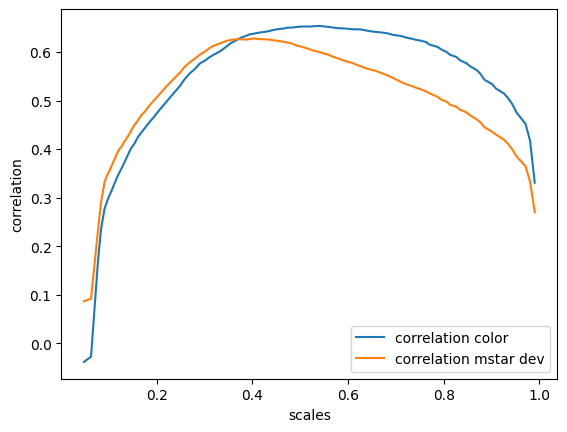

In [26]:
plt.plot(scales, corrs_color, label='correlation color')
plt.plot(scales, corrs_mstar_dev, label='correlation mstar dev')
plt.xlabel('scales')
plt.ylabel('correlation')
plt.legend()

# Train and Apply MultiCAM (Linear)

In [70]:
x = mah
# x = hydro_data['a12'][mpeak_mask].reshape(-1, 1)
y = np.stack([mstar_dev, gi_color[mpeak_mask]], axis=-1)
x.shape, y.shape

((11316, 100), (11316, 2))

In [71]:
model = MultiCAM(x.shape[1], 2)
model.fit(x,y)

In [72]:
y_pred = model.predict(x)
y_pred.shape

(11316, 2)

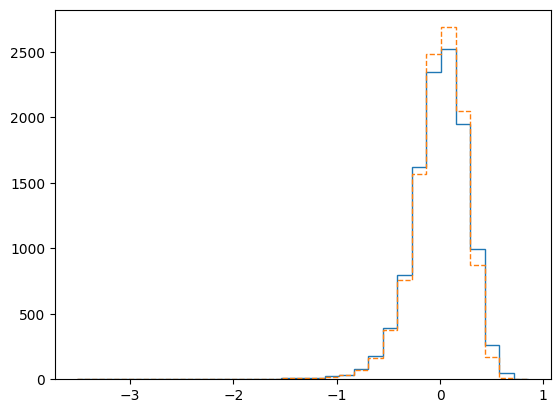

In [73]:
# check marginals 
_, bins, _ = plt.hist(y[:, 0], bins=31, histtype='step')
plt.hist(y_pred[:, 0], bins=bins, histtype='step', ls='--');


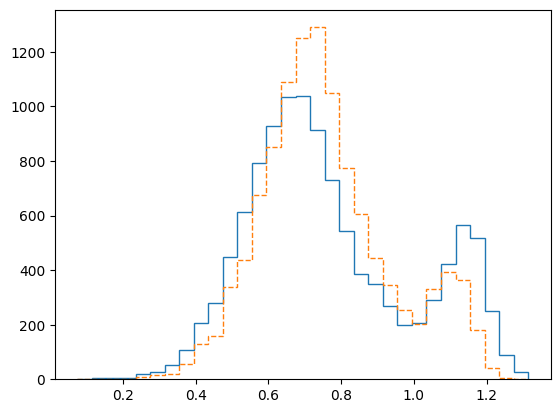

In [74]:
_, bins, _ = plt.hist(y[:, 1], bins=31, histtype='step')
plt.hist(y_pred[:, 1], bins=bins, histtype='step', ls='--');

In [75]:
# prediction spearmanr (these are what we expect I think)
spearmanr(y_pred[:, 0], y[:, 0]), spearmanr(y_pred[:, 1], y[:, 1])

(SignificanceResult(statistic=np.float64(0.671830927479139), pvalue=np.float64(0.0)),
 SignificanceResult(statistic=np.float64(0.7270175527734608), pvalue=np.float64(0.0)))

In [76]:
# obtain haloes within stellar mass bin 
_pred_mstar_dev = y_pred[:, 0]
_mpeak = mpeak[mpeak_mask]
pred_mstar = np.log10(10 ** (m * _mpeak + b) * 10**_mpeak) + _pred_mstar_dev
pred_stellar_mask = (pred_mstar > stellar_mass_bin[0]) & (pred_mstar < stellar_mass_bin[1])
sum(pred_stellar_mask)
# plt.plot(pred_mstar, smass, 'o')

np.int64(3546)

(array([272., 283., 270., 235., 207., 207., 188., 201., 171., 181., 158.,
        154., 147., 160., 134., 113.,  87., 101.,  98.,  90.,  83.]),
 array([ 9.50012016,  9.53342056,  9.56672001,  9.60002041,  9.63332081,
         9.66662025,  9.69992065,  9.73322105,  9.7665205 ,  9.7998209 ,
         9.8331213 ,  9.86642075,  9.89972115,  9.93302155,  9.96632099,
         9.99962139, 10.03292179, 10.06622124, 10.09952164, 10.13282204,
        10.16612148, 10.19942188]),
 [<matplotlib.patches.Polygon at 0x76cc4bd47250>])

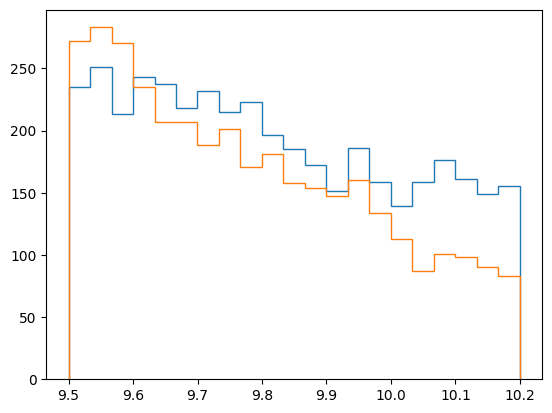

In [77]:
# stellar mass distribution compare between prediction and truth
_, bins, _ = plt.hist( np.log10(hydro_data['stellar_mass'][stellar_mask]), bins=21, histtype='step')
plt.hist(pred_mstar[pred_stellar_mask], bins=bins, histtype='step')

In [78]:
# split in red and yellow
smass = np.log10(hydro_data['stellar_mass'][stellar_mask])
mask_red = gi_color[stellar_mask] > 1.0
mask_blue = gi_color[stellar_mask] < 1.0 
smass_red = smass[mask_red]
smass_blue = smass[mask_blue]

pred_color = y_pred[:, 1][pred_stellar_mask]
pred_red_mask = pred_color > 1.0
pred_blue_mask = pred_color < 1.0 


smass_pred_red = pred_mstar[pred_stellar_mask][pred_red_mask]
smass_pred_blue = pred_mstar[pred_stellar_mask][pred_blue_mask]

In [79]:
smass_blue.shape, smass_red.shape, smass_pred_blue.shape, smass_pred_red.shape

((3072,), (983,), (2822,), (724,))

(array([2.34684815, 2.40011683, 2.44285558, 1.97348595, 1.74946862,
        1.67474819, 1.62145872, 1.70679866, 1.54674196, 1.46144635,
        1.34410394, 1.24809652, 1.26939512, 1.34410394, 1.15208909,
        0.94937954, 0.73605692, 0.90673679, 0.72538943, 0.76803738,
        0.68271946]),
 array([ 9.50012016,  9.53339767,  9.56667614,  9.59995365,  9.63323116,
         9.66650867,  9.69978714,  9.73306465,  9.76634216,  9.79962063,
         9.83289814,  9.86617565,  9.89945316,  9.93273163,  9.96600914,
         9.99928665, 10.03256512, 10.06584263, 10.09912014, 10.13239765,
        10.16567612, 10.19895363]),
 [<matplotlib.patches.Polygon at 0x76cc4b3b5950>])

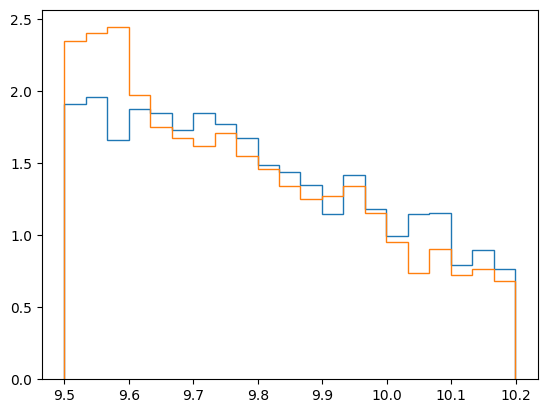

In [80]:
# stellar mass distribution compare between prediction and truth
_, bins, _ = plt.hist( smass_blue, bins=21, histtype='step', density=True)
plt.hist(smass_pred_blue, bins=bins, histtype='step', density=True)

(array([2.08718693, 2.42113684, 1.75323703, 2.04550183, 1.8367245 ,
        2.00369946, 1.50277459, 1.75323703, 1.08533721, 1.8367245 ,
        1.33583793, 1.46103085, 1.25231216, 1.33579964, 1.04359347,
        1.00184973, 0.83487477, 0.66791896, 1.2940559 , 0.62615608,
        0.87661851]),
 array([ 9.50071716,  9.53398895,  9.56726074,  9.60053253,  9.63380337,
         9.66707516,  9.70034695,  9.73361874,  9.76689053,  9.80016232,
         9.8334341 ,  9.86670494,  9.89997673,  9.93324852,  9.96652031,
         9.9997921 , 10.03306389, 10.06633568, 10.09960651, 10.1328783 ,
        10.16615009, 10.19942188]),
 [<matplotlib.patches.Polygon at 0x76cc4bd156d0>])

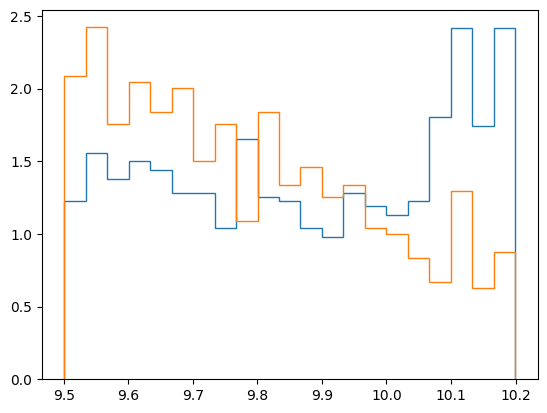

In [81]:
_, bins, _ = plt.hist( smass_red, bins=21, histtype='step', density=True)
plt.hist(smass_pred_red, bins=bins, histtype='step', density=True)

# Sampling

In [ ]:
x = mah
# x = hydro_data['a12'][mpeak_mask].reshape(-1, 1)
y = np.stack([mstar_dev, gi_color[mpeak_mask]], axis=-1)
x.shape, y.shape

((11316, 100), (11316, 2))

In [40]:
model = MultiCamSampling(x.shape[1], 2)
model.fit(x,y)

In [51]:
y_pred = model.sample(x)
y_pred.shape

(11316, 2)

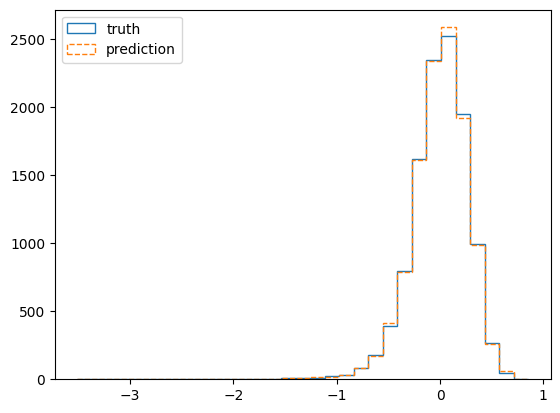

In [52]:
# check marginals 
_, bins, _ = plt.hist(y[:, 0], bins=31, histtype='step', label='truth')
plt.hist(y_pred[:, 0], bins=bins, histtype='step', ls='--', label='prediction');
plt.legend()


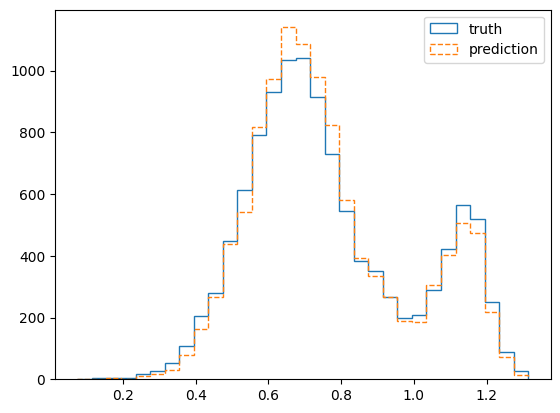

In [53]:
_, bins, _ = plt.hist(y[:, 1], bins=31, histtype='step', label='truth')
plt.hist(y_pred[:, 1], bins=bins, histtype='step', ls='--', label='prediction');
plt.legend()

In [54]:
# obtain haloes within stellar mass bin 
_pred_mstar_dev = y_pred[:, 0]
_mpeak = mpeak[mpeak_mask]
pred_mstar = np.log10(10 ** (m * _mpeak + b) * 10**_mpeak) + _pred_mstar_dev
pred_stellar_mask = (pred_mstar > stellar_mass_bin[0]) & (pred_mstar < stellar_mass_bin[1])
sum(pred_stellar_mask)
# plt.plot(pred_mstar, smass, 'o')

np.int64(3577)

(array([2.17557606, 2.24283955, 1.999178  , 1.86477948, 1.80603185,
        1.74718077, 1.90677902, 1.66322933, 1.59598244, 1.30198567,
        1.42802518, 1.31878549, 1.16758715, 1.20962133, 1.24318632,
        1.01638881, 1.00801777, 0.8903902 , 0.98278918, 0.6636117 ,
        0.79799122]),
 array([ 9.50012016,  9.53342056,  9.56672001,  9.60002041,  9.63332081,
         9.66662025,  9.69992065,  9.73322105,  9.7665205 ,  9.7998209 ,
         9.8331213 ,  9.86642075,  9.89972115,  9.93302155,  9.96632099,
         9.99962139, 10.03292179, 10.06622124, 10.09952164, 10.13282204,
        10.16612148, 10.19942188]),
 [<matplotlib.patches.Polygon at 0x76cc4ac2f110>])

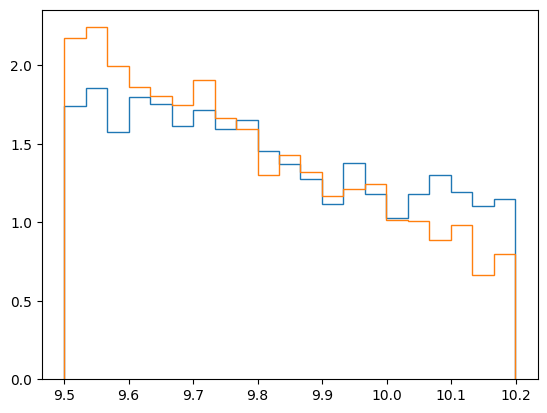

In [56]:
# stellar mass distribution compare between prediction and truth
_, bins, _ = plt.hist( np.log10(hydro_data['stellar_mass'][stellar_mask]), bins=21, histtype='step', density=True)
plt.hist(pred_mstar[pred_stellar_mask], bins=bins, histtype='step', density=True)

In [65]:
# split in red and yellow
smass = np.log10(hydro_data['stellar_mass'][stellar_mask])
mask_red = gi_color[stellar_mask] > 1.0
mask_blue = gi_color[stellar_mask] < 1.0 
smass_red = smass[mask_red]
smass_blue = smass[mask_blue]

pred_color = y_pred[:, 1][pred_stellar_mask]
pred_red_mask = pred_color > 1.0
pred_blue_mask = pred_color < 1.0 


smass_pred_red = pred_mstar[pred_stellar_mask][pred_red_mask]
smass_pred_blue = pred_mstar[pred_stellar_mask][pred_blue_mask]

In [66]:
smass_blue.shape, smass_red.shape, smass_pred_blue.shape, smass_pred_red.shape

((3072,), (983,), (2755,), (822,))

(array([2.24858943, 2.22669466, 2.0193643 , 1.91020947, 1.75739271,
        1.79008786, 1.81197013, 1.59366047, 1.68093616, 1.33168889,
        1.42992823, 1.24436503, 1.14609284, 1.2007031 , 1.28802696,
        1.03694114, 1.11337923, 0.86232313, 0.98239344, 0.6876557 ,
        0.68767541]),
 array([ 9.50012016,  9.53339767,  9.56667614,  9.59995365,  9.63323116,
         9.66650867,  9.69978714,  9.73306465,  9.76634216,  9.79962063,
         9.83289814,  9.86617565,  9.89945316,  9.93273163,  9.96600914,
         9.99928665, 10.03256512, 10.06584263, 10.09912014, 10.13239765,
        10.16567612, 10.19895363]),
 [<matplotlib.patches.Polygon at 0x76cc4bcdac10>])

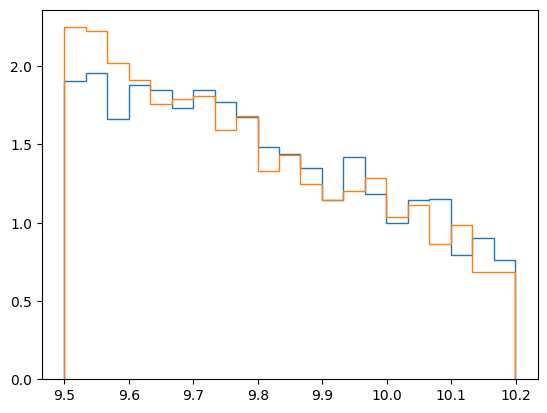

In [68]:
# stellar mass distribution compare between prediction and truth
_, bins, _ = plt.hist( smass_blue, bins=21, histtype='step', density=True)
plt.hist(smass_pred_blue, bins=bins, histtype='step', density=True)

(array([1.94024491, 2.30632885, 1.9768533 , 1.68403442, 1.9768533 ,
        1.61076936, 2.30632885, 1.72059454, 1.39111899, 1.24468541,
        1.46437775, 1.50094417, 1.20807702, 1.24468541, 1.13486023,
        0.91520986, 0.73216789, 0.98845498, 0.91520986, 0.62234271,
        1.17146862]),
 array([ 9.50071716,  9.53398895,  9.56726074,  9.60053253,  9.63380337,
         9.66707516,  9.70034695,  9.73361874,  9.76689053,  9.80016232,
         9.8334341 ,  9.86670494,  9.89997673,  9.93324852,  9.96652031,
         9.9997921 , 10.03306389, 10.06633568, 10.09960651, 10.1328783 ,
        10.16615009, 10.19942188]),
 [<matplotlib.patches.Polygon at 0x76cc4c015a90>])

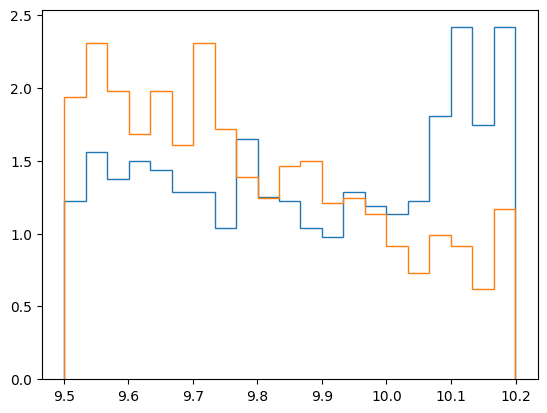

In [69]:
_, bins, _ = plt.hist( smass_red, bins=21, histtype='step', density=True)
plt.hist(smass_pred_red, bins=bins, histtype='step', density=True)